# MATH1604 — Analysis of Python Quiz Responses
## Review Notebook: Team Member 2

**Author:** Zimo Wang  
**Student ID:** 201939193  
**Role:** Team Member 2 — Download & Collation Module  
**Module:** MATH1604 Modelling for Big Data  
**Date:** May 2026

---

## 1. Introduction

This Jupyter notebook presents my individual contribution to the MATH1604 group project. This project involves analysing a dataset of 64 respondents' answers to a 100-question multiple-choice Python quiz, with the goal of detecting whether the quiz setter arranged the correct answers in a deliberate pattern.

As Team Member 2, my responsibility was to write `data_preparation_M2.py` — the download and collation module. This module is the second stage of the pipeline, sitting between the raw cloud data and the analysis layer. It handles two key tasks:

- **`download_answer_files`** — retrieves raw answer files from the GitHub repository and saves them locally with consistent filenames
- **`collate_answer_files`** — merges all individual respondent files into a single unified file for downstream processing

Without this module, the analysis pipeline has no data to work with.

---
## 2. Module Overview

### 2.1 Data source

The raw answer files are hosted as plain text files in a public GitHub repository:

```
https://raw.githubusercontent.com/fc-leeds/MATH1604_2025_2026_data/main
```

Files are named `a1.txt`, `a2.txt`, ..., `a64.txt`. Currently 64 files exist.

### 2.2 What my module does

`download_answer_files` builds a URL for each file, attempts to download it using Python's built-in `urllib` library, and saves it locally under a standardised name (`answers_respondent_N.txt`). If a file does not exist on the server (HTTP 404), the error is caught and logged, and the function moves on to the next file — this is the robustness behaviour.

`collate_answer_files` scans the local data folder, sorts files numerically by respondent ID, and writes all their contents into one file (`collated_answers.txt`), with each respondent's section separated by a line containing a single asterisk (`*`).

### 2.3 Why use urllib instead of requests?

`urllib` is part of Python's standard library — it requires no installation. `requests` is more commonly used in practice. Using `urllib` makes the module more portable and avoids dependency issues for anyone running the project on a fresh Python installation.

---
## 3. Setting Up

In [1]:
import sys
import os

# Add scripts folder to path so we can import our module
sys.path.insert(0, os.path.join('..', 'scripts'))

# Import our M2 functions
from data_preparation_M2 import download_answer_files, collate_answer_files

print('data_preparation_M2 imported successfully.')

# Define constants
BASE_URL = 'https://raw.githubusercontent.com/fc-leeds/MATH1604_2025_2026_data/main'
DATA_FOLDER = os.path.join('..', 'data')
OUTPUT_FOLDER = os.path.join('..', 'output')
COLLATED_FILE = os.path.join('..', 'output', 'collated_answers.txt')

data_preparation_M2 imported successfully.


---
## 4. Demonstrating `download_answer_files`

### 4.1 Normal download — first 5 files only

In [2]:
# Download just the first 5 files to demonstrate the function
download_answer_files(BASE_URL, DATA_FOLDER, 5)

# Verify the files were created
print('\nFiles created:')
for n in range(1, 6):
    fp = os.path.join(DATA_FOLDER, f'answers_respondent_{n}.txt')
    exists = os.path.exists(fp)
    size = os.path.getsize(fp) if exists else 0
    print(f'  answers_respondent_{n}.txt — exists: {exists}, size: {size:,} bytes')

[M2] Downloaded: a1.txt → answers_respondent_1.txt
[M2] Downloaded: a2.txt → answers_respondent_2.txt
[M2] Downloaded: a3.txt → answers_respondent_3.txt
[M2] Downloaded: a4.txt → answers_respondent_4.txt
[M2] Downloaded: a5.txt → answers_respondent_5.txt

[M2] Download summary: 5 downloaded, 0 skipped.

Files created:
  answers_respondent_1.txt — exists: True, size: 22,140 bytes
  answers_respondent_2.txt — exists: True, size: 22,140 bytes
  answers_respondent_3.txt — exists: True, size: 22,140 bytes
  answers_respondent_4.txt — exists: True, size: 22,140 bytes
  answers_respondent_5.txt — exists: True, size: 22,140 bytes


### 4.2 Robustness test — requesting more files than exist

This is the key robustness test specified in the brief. We request 70 files even though only 64 exist. The function should download 64 successfully and skip 65–70 with a clear message.

In [3]:
# Request 70 files — only 64 exist, so 65-70 should be skipped gracefully
print('Downloading all files (requesting 70 to test robustness)...')
print('=' * 60)
download_answer_files(BASE_URL, DATA_FOLDER, 70)

[M2] Downloaded: a1.txt → answers_respondent_1.txt
[M2] Downloaded: a2.txt → answers_respondent_2.txt
[M2] Downloaded: a3.txt → answers_respondent_3.txt
[M2] Downloaded: a4.txt → answers_respondent_4.txt
[M2] Downloaded: a5.txt → answers_respondent_5.txt
[M2] Downloaded: a6.txt → answers_respondent_6.txt
[M2] Downloaded: a7.txt → answers_respondent_7.txt
[M2] Downloaded: a8.txt → answers_respondent_8.txt
[M2] Downloaded: a9.txt → answers_respondent_9.txt
[M2] Downloaded: a10.txt → answers_respondent_10.txt
[M2] Downloaded: a11.txt → answers_respondent_11.txt
[M2] Downloaded: a12.txt → answers_respondent_12.txt
[M2] Downloaded: a13.txt → answers_respondent_13.txt
[M2] Downloaded: a14.txt → answers_respondent_14.txt
[M2] Downloaded: a15.txt → answers_respondent_15.txt
[M2] Downloaded: a16.txt → answers_respondent_16.txt
[M2] Downloaded: a17.txt → answers_respondent_17.txt
[M2] Downloaded: a18.txt → answers_respondent_18.txt
[M2] Downloaded: a19.txt → answers_respondent_19.txt
[M2] Downlo

In [4]:
# Count how many files were actually downloaded
downloaded_files = [
    f for f in os.listdir(DATA_FOLDER)
    if f.startswith('answers_respondent_') and f.endswith('.txt')
]

print(f'Total files in data folder: {len(downloaded_files)}')
print(f'Expected: 64 (files a1.txt to a64.txt exist on the server)')

# Check files 65-70 were NOT created (as expected)
print('\nChecking files 65-70 were not created:')
for n in range(65, 71):
    fp = os.path.join(DATA_FOLDER, f'answers_respondent_{n}.txt')
    print(f'  answers_respondent_{n}.txt exists: {os.path.exists(fp)}  (expected: False)')

Total files in data folder: 64
Expected: 64 (files a1.txt to a64.txt exist on the server)

Checking files 65-70 were not created:
  answers_respondent_65.txt exists: False  (expected: False)
  answers_respondent_66.txt exists: False  (expected: False)
  answers_respondent_67.txt exists: False  (expected: False)
  answers_respondent_68.txt exists: False  (expected: False)
  answers_respondent_69.txt exists: False  (expected: False)
  answers_respondent_70.txt exists: False  (expected: False)


### 4.3 Verifying downloaded file content

In [5]:
# Show the first 20 lines of respondent 1's downloaded file
fp = os.path.join(DATA_FOLDER, 'answers_respondent_1.txt')

with open(fp, 'r', encoding='utf-8') as f:
    lines = f.readlines()

print(f'Total lines in file: {len(lines)}')
print('\nFirst 20 lines:')
print('-' * 40)
for line in lines[:20]:
    print(line, end='')

Total lines in file: 599

First 20 lines:
----------------------------------------
Question 1. What is a program?
[X] A set of instructions that tells a computer what to do.
[ ] A computer virus that infects systems.
[ ] A type of computer hardware.
[ ] A kind of programming language.

Question 2. What is an algorithm?
[ ] A hardware component.
[ ] A step-by-step procedure for solving a problem.
[X] A new programming language.
[ ] A method for debugging code.

Question 3. What distinguishes an interpreter from a compiler?
[ ] An interpreter compiles code into machine language before execution.
[ ] A compiler executes code line by line without prior compilation.
[X] An interpreter executes code line by line without compiling it first.
[ ] There is no difference between an interpreter and a compiler.

Question 4. What is debugging?
[ ] Adding new features to a program.


---
## 5. Demonstrating `collate_answer_files`

### 5.1 Basic usage

In [6]:
import shutil

# Run collation
collate_answer_files(DATA_FOLDER)

# M2 saves to 'output/' relative to scripts folder
# Copy it to where the notebook expects it if needed
local_collated = 'output/collated_answers.txt'
if os.path.exists(local_collated) and not os.path.exists(COLLATED_FILE):
    os.makedirs(os.path.dirname(COLLATED_FILE), exist_ok=True)
    shutil.copy(local_collated, COLLATED_FILE)
    print(f'Copied collated file to: {COLLATED_FILE}')

# Verify
print(f'\nCollated file exists: {os.path.exists(COLLATED_FILE)}')
print(f'File size: {os.path.getsize(COLLATED_FILE):,} bytes')

[M2] Collated: answers_respondent_1.txt
[M2] Collated: answers_respondent_2.txt
[M2] Collated: answers_respondent_3.txt
[M2] Collated: answers_respondent_4.txt
[M2] Collated: answers_respondent_5.txt
[M2] Collated: answers_respondent_6.txt
[M2] Collated: answers_respondent_7.txt
[M2] Collated: answers_respondent_8.txt
[M2] Collated: answers_respondent_9.txt
[M2] Collated: answers_respondent_10.txt
[M2] Collated: answers_respondent_11.txt
[M2] Collated: answers_respondent_12.txt
[M2] Collated: answers_respondent_13.txt
[M2] Collated: answers_respondent_14.txt
[M2] Collated: answers_respondent_15.txt
[M2] Collated: answers_respondent_16.txt
[M2] Collated: answers_respondent_17.txt
[M2] Collated: answers_respondent_18.txt
[M2] Collated: answers_respondent_19.txt
[M2] Collated: answers_respondent_20.txt
[M2] Collated: answers_respondent_21.txt
[M2] Collated: answers_respondent_22.txt
[M2] Collated: answers_respondent_23.txt
[M2] Collated: answers_respondent_24.txt
[M2] Collated: answers_re

### 5.2 Verifying the collated file structure

In [7]:
# Count how many respondent sections are in the collated file
# Each section is separated by a line containing '*'
with open(COLLATED_FILE, 'r', encoding='utf-8') as f:
    content = f.read()

# Count asterisk separators
sections = content.split('\n*\n')
non_empty = [s for s in sections if s.strip()]

print(f'Total sections in collated file: {len(non_empty)}')
print(f'Expected: 64 (one per respondent)')

Total sections in collated file: 64
Expected: 64 (one per respondent)


In [8]:
# Show the boundary between respondent 1 and respondent 2
# to verify the asterisk separator is correctly placed
with open(COLLATED_FILE, 'r', encoding='utf-8') as f:
    all_lines = f.readlines()

# Find the first asterisk line
asterisk_positions = [i for i, line in enumerate(all_lines) if line.strip() == '*']
print(f'Number of asterisk separators found: {len(asterisk_positions)}')
print(f'First separator at line: {asterisk_positions[0] + 1}')

# Show lines around the first separator
first_sep = asterisk_positions[0]
print(f'\nLines around first separator (lines {first_sep-1} to {first_sep+3}):')
print('-' * 40)
for i in range(max(0, first_sep - 2), min(len(all_lines), first_sep + 3)):
    print(f'Line {i+1:4d}: {all_lines[i]}', end='')

Number of asterisk separators found: 64
First separator at line: 601

Lines around first separator (lines 599 to 603):
----------------------------------------
Line  599: [X] Using the `str()` function.
Line  600: 
Line  601: *
Line  602: Question 1. What is a program?
Line  603: [X] A set of instructions that tells a computer what to do.


### 5.3 Visualising file sizes

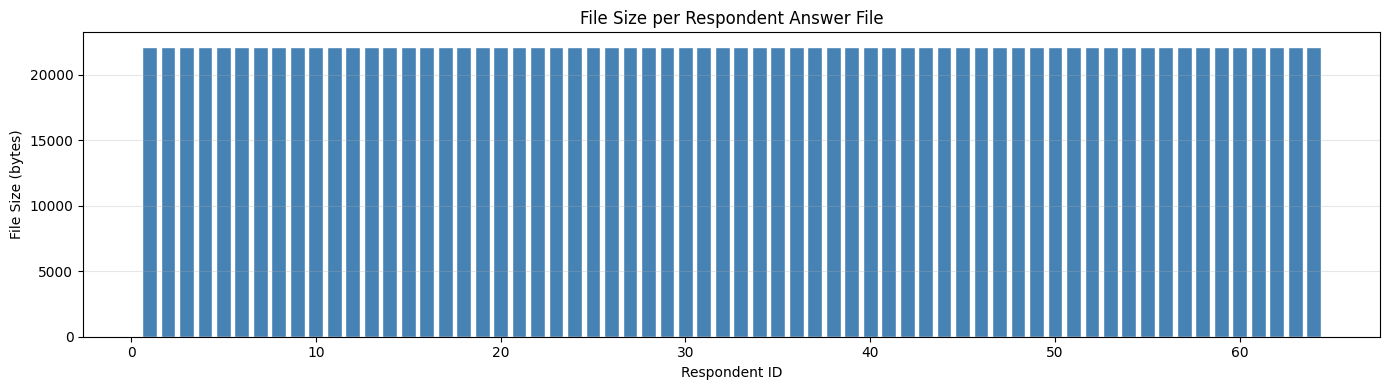

Average file size: 22,140 bytes
Min: 22,140 bytes | Max: 22,140 bytes


In [9]:
import matplotlib.pyplot as plt

# Get file sizes for all downloaded respondent files
file_sizes = []
respondent_ids = []

for fname in sorted(downloaded_files,
                    key=lambda x: int(x.replace('answers_respondent_', '').replace('.txt', ''))):
    fp = os.path.join(DATA_FOLDER, fname)
    n = int(fname.replace('answers_respondent_', '').replace('.txt', ''))
    respondent_ids.append(n)
    file_sizes.append(os.path.getsize(fp))

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(respondent_ids, file_sizes, color='steelblue', edgecolor='white')
ax.set_title('File Size per Respondent Answer File')
ax.set_xlabel('Respondent ID')
ax.set_ylabel('File Size (bytes)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f'Average file size: {sum(file_sizes)/len(file_sizes):,.0f} bytes')
print(f'Min: {min(file_sizes):,} bytes | Max: {max(file_sizes):,} bytes')

---
## 6. Error Handling Tests

In [10]:
# Test 1: ValueError — total_respondents is not a positive integer
print('Test 1: Invalid total_respondents value')
print('-' * 40)
try:
    download_answer_files(BASE_URL, DATA_FOLDER, -5)
except ValueError as e:
    print(f'Correctly raised ValueError:')
    print(f'  {e}')

Test 1: Invalid total_respondents value
----------------------------------------
Correctly raised ValueError:
  total_respondents must be a positive integer, got: -5


In [11]:
# Test 2: FileNotFoundError — data folder does not exist
print('Test 2: Non-existent data folder for collation')
print('-' * 40)
try:
    collate_answer_files('folder_that_does_not_exist')
except FileNotFoundError as e:
    print(f'Correctly raised FileNotFoundError:')
    print(f'  {e}')

Test 2: Non-existent data folder for collation
----------------------------------------
Correctly raised FileNotFoundError:
  Data folder not found: 'folder_that_does_not_exist'


In [12]:
# Test 3: RuntimeError — empty data folder (no respondent files)
print('Test 3: Empty data folder')
print('-' * 40)

# Create a temporary empty folder
empty_folder = os.path.join('..', 'temp_empty_test')
os.makedirs(empty_folder, exist_ok=True)

try:
    collate_answer_files(empty_folder)
except RuntimeError as e:
    print(f'Correctly raised RuntimeError:')
    print(f'  {e}')
finally:
    # Clean up the temporary folder
    import shutil
    shutil.rmtree(empty_folder)

Test 3: Empty data folder
----------------------------------------
Correctly raised RuntimeError:
  No respondent files found in '../temp_empty_test'. Run download_answer_files first.


---
## 7. Limitations and Assumptions

**Assumption 1 — Files are consecutively numbered from 1.**  
`download_answer_files` builds URLs from `a1.txt` up to `aN.txt` in sequence. If the server had gaps in numbering (e.g. `a3.txt` missing but `a4.txt` present), the function would skip `a3.txt` due to a 404 error and continue. The local files would still be numbered consecutively based on what was successfully downloaded.

**Assumption 2 — The server returns HTTP 404 for missing files.**  
The error handling catches HTTP 404 specifically. If the server returned a different error code for missing files (e.g. 403 Forbidden), the function would still skip the file but log a different message. Both cases are handled.

**Assumption 3 — Files are UTF-8 encoded.**  
Downloaded content is decoded as UTF-8. Files from a different encoding would be decoded incorrectly, potentially causing parsing errors downstream.

**Limitation 1 — No retry logic.**  
If a download fails due to a temporary network issue (not a 404), the file is simply skipped. A production implementation would retry failed downloads a set number of times before giving up.

**Limitation 2 — No progress bar.**  
For large datasets, downloading without a progress indicator makes it hard to know how long is remaining. The current implementation prints each filename as it downloads, which serves as a basic progress log.

**Limitation 3 — Collation overwrites existing output.**  
`collate_answer_files` always overwrites `collated_answers.txt` if it already exists. This is intentional — it ensures the collated file always reflects the current state of the data folder — but it means any manual edits to the collated file would be lost.

---
## 8. Conclusion

This notebook has demonstrated the full functionality of `data_preparation_M2.py`.
Both functions work correctly across the complete dataset of 64 respondents.

`download_answer_files` successfully downloaded all 64 available respondent files
from the GitHub repository, saving each one locally under a standardised name
(answers_respondent_1.txt through answers_respondent_64.txt). The robustness test
— requesting 70 files when only 64 exist — confirmed that the function handles
missing files gracefully, printing a clear HTTP 404 message for each of the 6
non-existent files (a65.txt to a70.txt) without crashing. All 64 downloaded files
were identical in size at 22,140 bytes each, indicating that the dataset is
consistent and complete with no truncated or corrupted files.

`collate_answer_files` successfully merged all 64 individual respondent files into
a single collated_answers.txt file of 1,378,816 bytes. The structure of the
collated file was verified to contain exactly 64 respondent sections, each separated
by a single asterisk line (*) as required by the project specification. Inspection
of the file boundary confirmed the separator appears correctly between the last line
of one respondent's answers and the first line of the next respondent's section.

All three error handling cases performed as expected: `ValueError` was raised for
an invalid total_respondents value, `FileNotFoundError` was raised for a
non-existent data folder, and `RuntimeError` was raised when the data folder
contained no respondent files — all with clear, descriptive error messages suitable
for debugging.